In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import plotly.figure_factory as ff
import plotly.offline as py
from scipy.stats import shapiro
from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency

from graphviz import Digraph
import matplotlib.colors as mcolors

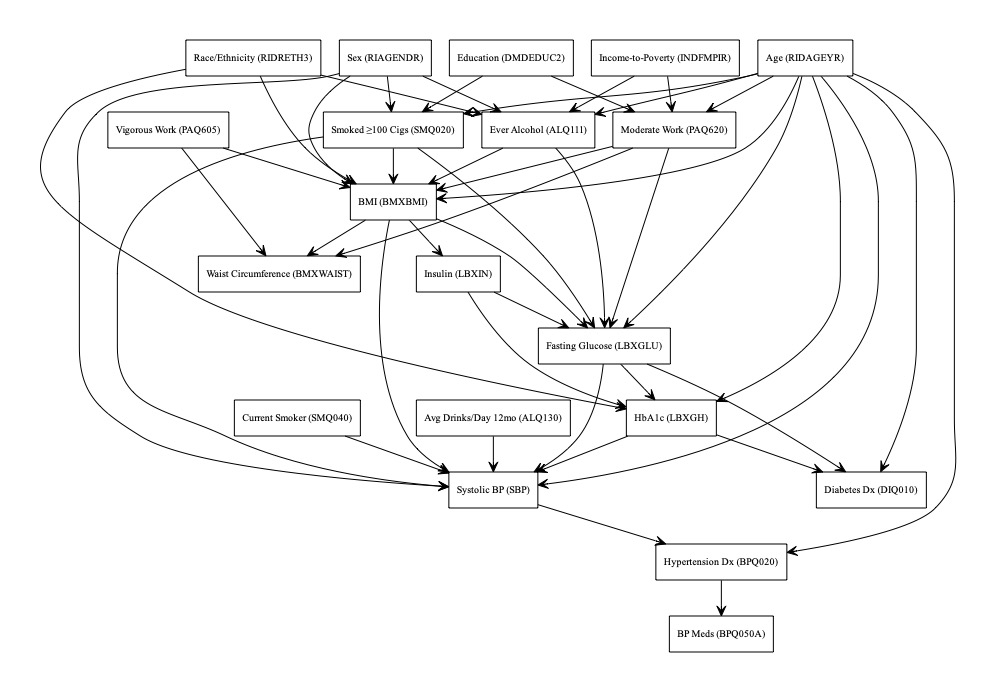

In [2]:
from IPython.display import Image
Image("NHANES_BN_Expanded.jpg")

# Load dataset
### NHANES 2017-March 2020 Pre-pandemic
https://wwwn.cdc.gov/nchs/nhanes/continuousnhanes/default.aspx?Cycle=2017-2020 \
The NHANES program suspended field operations in March 2020 due to the coronavirus disease 2019 (COVID-19) pandemic.

# List of attributes
* https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_DEMO.htm
  * **RIDAGEYR**: Age in years, at the time of the screening interview
  * **RIAGENDR**: Gender of the participant
      * Code: 1: Male; 2: Female, .: Missing
  * **RIDRETH3**: Recode of reported race and Hispanic origin information, with Non-Hispanic Asian Category
      * Code:
  * **DMDEDUC2**: Education level - Adults 20+
  * **INDFMPIR**: Ratio of family income to poverty
* https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_BMX.htm
    * **BMXBMI**: Body Mass Index (kg/m**2)
    * **BMXWAIST**: Waist Circumference (cm)
<br/>
* https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_ALQ.htm
    * **ALQ111**: Ever had a drink of any kind of alcohol
    * **ALQ130**: Avg # alcoholic drinks/day - past 12 mos
<br/>
* https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_BPQ.htm
    * **BPQ020**: Ever told you had high blood pressure
    * **BPQ050A**: Now taking prescribed medicine for HBP
<br/>
* https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_DIQ.htm
    * **DIQ010**: Doctor told you have diabetes
<br/>
* https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_SMQ.htm
    * **SMQ020**: Smoked at least 100 cigarettes in life
    * **SMQ040**: {Do you/Does SP} now smoke cigarettes?
<br/>
* https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_PAQ.htm
    * **PAQ605**: Vigorous work activity
    * **PAQ620**: Moderate work activity

* https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_GLU.htm
    * ***LBXGLU***: Fasting Glucose (mg/dL)

* https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_INS.htm
    * **LBXIN**: Insulin (μU/mL)

* https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_GHB.htm
    * **LBXGH**: HbA1c (Glycohemoglobin (%))


In [3]:
demo = pd.read_sas("./dataset/P_DEMO.xpt")
bmx = pd.read_sas("./dataset/P_BMX.xpt")
alq = pd.read_sas("./dataset/P_ALQ.xpt")
bpq = pd.read_sas("./dataset/P_BPQ.xpt")
diq = pd.read_sas("./dataset/P_DIQ.xpt")
smq = pd.read_sas("./dataset/P_SMQ.xpt")
paq = pd.read_sas("./dataset/P_PAQ.xpt")
glu = pd.read_sas("./dataset/P_GLU.xpt")
ins = pd.read_sas("./dataset/P_INS.xpt")
ghb = pd.read_sas("./dataset/P_GHB.xpt")

In [4]:
demo_cols = ["SEQN", "RIDAGEYR", "RIAGENDR", "RIDRETH3", "DMDEDUC2", "INDFMPIR"]
bmx_cols = ["SEQN", "BMXBMI", "BMXWAIST"]
alq_cols = ["SEQN", "ALQ111", "ALQ130"]
bpq_cols = ["SEQN", "BPQ020", "BPQ050A"]
diq_cols = ["SEQN", "DIQ010"]
smq_cols = ["SEQN", "SMQ020", "SMQ040"]
paq_cols = ["SEQN", "PAQ605", "PAQ620"]
glu_cols = ["SEQN", "LBXGLU"]
ins_cols = ["SEQN", "LBXIN"]
ghb_cols = ["SEQN", "LBXGH"]

demo_sel = demo[demo_cols]
bmx_sel = bmx[bmx_cols]
alq_sel = alq[alq_cols]
bpq_sel = bpq[bpq_cols]
diq_sel = diq[diq_cols]
smq_sel = smq[smq_cols]
paq_sel = paq[paq_cols]
glu_sel = glu[glu_cols]
ins_sel = ins[ins_cols]
ghb_sel = ghb[ghb_cols]

In [5]:
merged = demo_sel.merge(bmx_sel, on="SEQN", how="inner")
merged = merged.merge(alq_sel, on="SEQN", how="inner")
merged = merged.merge(bpq_sel, on="SEQN", how="inner")
merged = merged.merge(diq_sel, on="SEQN", how="inner")
merged = merged.merge(smq_sel, on="SEQN", how="inner")
merged = merged.merge(paq_sel, on="SEQN", how="inner")
merged = merged.merge(glu_sel, on="SEQN", how="inner")
merged = merged.merge(ins_sel, on="SEQN", how="inner")
merged = merged.merge(ghb_sel, on="SEQN", how="inner")
data = merged

# Explore structure of the dataset

In [6]:
data.head()

,SEQN,RIDAGEYR,RIAGENDR,RIDRETH3,DMDEDUC2,INDFMPIR,BMXBMI,BMXWAIST,ALQ111,ALQ130,BPQ020,BPQ050A,DIQ010,SMQ020,SMQ040,PAQ605,PAQ620,LBXGLU,LBXIN,LBXGH
0,109271.0,49.0,1.0,3.0,2.0,NaN,29.7,120.4,1.0,NaN,2.0,NaN,2.0,1.0,1.0,2.0,1.0,103.0,16.96,5.6
1,109274.0,68.0,1.0,7.0,4.0,1.20,30.2,109.6,1.0,2.0,1.0,1.0,1.0,2.0,NaN,1.0,1.0,154.0,13.52,5.7
2,109282.0,76.0,1.0,3.0,5.0,3.61,26.6,NaN,1.0,NaN,1.0,1.0,2.0,1.0,3.0,2.0,2.0,95.0,7.49,5.5
3,109286.0,33.0,2.0,6.0,5.0,1.36,28.9,NaN,NaN,NaN,2.0,NaN,2.0,2.0,NaN,2.0,2.0,92.0,16.46,5.7
4,109290.0,68.0,2.0,4.0,5.0,5.00,28.1,92.0,1.0,NaN,1.0,1.0,1.0,2.0,NaN,2.0,1.0,106.0,20.25,8.4


In [7]:
data.describe()

,SEQN,RIDAGEYR,RIAGENDR,RIDRETH3,DMDEDUC2,INDFMPIR,BMXBMI,BMXWAIST,ALQ111,ALQ130,BPQ020,BPQ050A,DIQ010,SMQ020,SMQ040,PAQ605,PAQ620,LBXGLU,LBXIN,LBXGH
count,4438.00000,4438.000000,4438.000000,4438.000000,4252.000000,3.808000e+03,4348.000000,4201.000000,4165.000000,2906.000000,4438.000000,1529.000000,4438.000000,4438.000000,1828.000000,4438.000000,4438.000000,4173.000000,4079.000000,4204.000000
mean,117186.32064,49.629338,1.518026,3.495268,3.527752,2.555622e+00,29.812626,100.174387,1.097479,3.556091,1.630239,1.155657,1.876070,1.592384,2.222101,1.754845,1.575710,112.913012,15.031954,5.851308
std,4498.47671,18.292069,0.499731,1.606655,1.212897,1.615405e+00,7.720594,17.473019,0.296645,32.071829,0.544239,0.362649,0.438161,0.522994,0.919838,0.479292,0.542962,37.525950,23.963639,1.136493
min,109271.00000,18.000000,1.000000,1.000000,1.000000,5.397605e-79,14.900000,61.100000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,47.000000,0.710000,2.800000
25%,113333.25000,34.000000,1.000000,3.000000,3.000000,1.180000e+00,24.600000,87.500000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,95.000000,6.170000,5.300000
50%,117247.00000,51.000000,2.000000,3.000000,4.000000,2.190000e+00,28.500000,98.700000,1.000000,2.000000,2.000000,1.000000,2.000000,2.000000,3.000000,2.000000,2.000000,103.000000,10.010000,5.600000
75%,121077.75000,64.000000,2.000000,4.000000,4.000000,4.080000e+00,33.600000,111.200000,1.000000,3.000000,2.000000,1.000000,2.000000,2.000000,3.000000,2.000000,2.000000,114.000000,16.565000,6.000000
max,124822.00000,80.000000,2.000000,7.000000,9.000000,5.000000e+00,92.300000,178.000000,2.000000,999.000000,9.000000,2.000000,9.000000,9.000000,3.000000,9.000000,9.000000,451.000000,512.500000,15.400000


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4438 entries, 0 to 4437
Data columns (total 20 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SEQN      4438 non-null   float64
 1   RIDAGEYR  4438 non-null   float64
 2   RIAGENDR  4438 non-null   float64
 3   RIDRETH3  4438 non-null   float64
 4   DMDEDUC2  4252 non-null   float64
 5   INDFMPIR  3808 non-null   float64
 6   BMXBMI    4348 non-null   float64
 7   BMXWAIST  4201 non-null   float64
 8   ALQ111    4165 non-null   float64
 9   ALQ130    2906 non-null   float64
 10  BPQ020    4438 non-null   float64
 11  BPQ050A   1529 non-null   float64
 12  DIQ010    4438 non-null   float64
 13  SMQ020    4438 non-null   float64
 14  SMQ040    1828 non-null   float64
 15  PAQ605    4438 non-null   float64
 16  PAQ620    4438 non-null   float64
 17  LBXGLU    4173 non-null   float64
 18  LBXIN     4079 non-null   float64
 19  LBXGH     4204 non-null   float64
dtypes: float64(20)
memory usage: 6

# What is diabetes?
Acccording to NIH, "Diabetes is a disease that occurs when your blood glucose, also called blood sugar, is too high. Blood glucose is your main source of energy and comes from the food you eat. Insulin, a hormone made by the pancreas, helps glucose from food get into your cells to be used for energy. Sometimes your body doesn’t make enough—or any—insulin or doesn’t use insulin well. Glucose then stays in your blood and doesn’t reach your cells.

Over time, having too much glucose in your blood can cause health problems. Although diabetes has no cure, you can take steps to manage your diabetes and stay healthy.

Sometimes people call diabetes “a touch of sugar” or “borderline diabetes.” These terms suggest that someone doesn’t really have diabetes or has a less serious case, but every case of diabetes is serious.

### Diabete risk
According to the diagnostic criteria established by the American Diabetes Association (ADA), diabetes can be identified through elevated fasting glucose (≥ 126 mg/dL), hemoglobin A1c (≥ 6.5%). In this project, we further include self-reported doctor diagnosis (DIQ010 == 1), and fasting insulin (≥ 15 μU/mL) as a marker of insulin resistance to capture individuals at early metabolic risk.

Such that, Diabetes risk was defined as 1 (at risk) if any of the following criteria were met:
- Fasting glucose (LBXGLU) ≥ 126 mg/dL
- Fasting insulin (LBXIN) ≥ 15 μU/mL
- Hemoglobin A1c (LBXGH) ≥ 6.5%
- Self-reported diabetes diagnosis (DIQ010 = 1, “Yes”)

Participants with none of these indicators were classified as no diabetes risk (0).

Participants with all of these values missing were classified as unknown (2).

In [9]:
def determine_diabetes_risk(row):
    # Missing case: all diabetes-related variables missing
    if (
        pd.isna(row['LBXGLU']) and
        pd.isna(row['LBXIN']) and
        pd.isna(row['LBXGH']) and
        pd.isna(row['DIQ010'])
    ):
        return 2  # Missing Data

    # Diabetes risk case
    if (
        (pd.notna(row['LBXGLU']) and row['LBXGLU'] >= 126) or
        (pd.notna(row['LBXIN']) and row['LBXIN'] >= 15) or
        (pd.notna(row['LBXGH']) and row['LBXGH'] >= 6.5) or
        (pd.notna(row['DIQ010']) and row['DIQ010'] == 1)
    ):
        return 1  # Diabetes Risk

    # Otherwise no risk
    return 0


# Apply function
data['diabetes_risk'] = data.apply(determine_diabetes_risk, axis=1)

# Convert to category and rename levels properly
data['diabetes_risk'] = data['diabetes_risk'].astype('category')
data['diabetes_risk'] = data['diabetes_risk'].cat.rename_categories({
    0: 'No Diabetes Risk',
    1: 'Diabetes Risk',
    2: 'Missing Data'
})

# Check counts
data['diabetes_risk'].value_counts()

diabetes_risk
No Diabetes Risk    2730
Diabetes Risk       1708
Name: count, dtype: int64

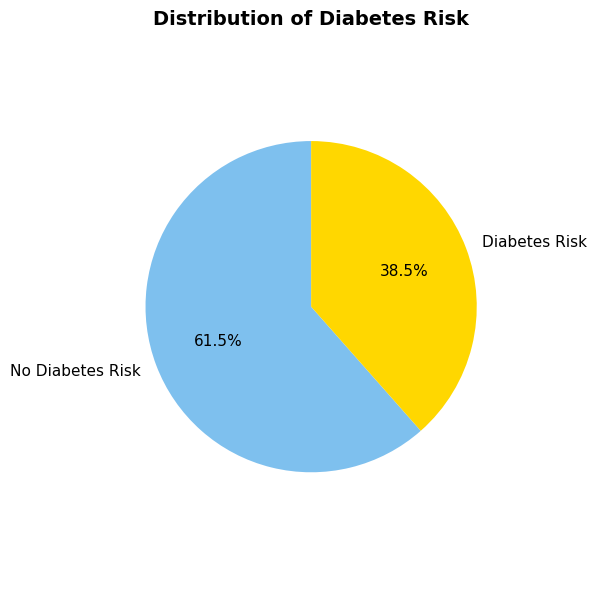

In [10]:
counts = data['diabetes_risk'].value_counts()

# Create pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    counts,
    labels=counts.index,            # category names
    autopct='%1.1f%%',              # show percentage
    startangle=90,                  # rotate so first slice starts at top
    colors=['#7EC0EE', '#FFD700', '#CCCCCC'],  # optional colors
    textprops={'fontsize': 11}      # font size for labels
)

# Add title
plt.title('Distribution of Diabetes Risk', fontsize=14, weight='bold')

# Equal aspect ratio ensures pie is circular
plt.axis('equal')
plt.tight_layout()
plt.show()

## Handling Missing Data

NHANES includes special nonresponse codes to represent different types of missingness across survey variables.  
The primary codes and their interpretations are as follows:

- **Code = 7 (“Refused”)** → *Missing Not at Random (MNAR)*:  
  Participants who refused to answer may differ systematically from others (e.g., individuals with sensitive or extreme values).

- **Code = 9 (“Don’t know”)** → *Missing at Random (MAR)*:  
  Missingness may depend on other observed characteristics (such as education or cognitive ability) but not directly on the true value.

- **Codes = 777 / 999 (“Missing” or “Not applicable”)** → *Likely MAR or MCAR*:  
  These typically occur due to instrument limits, data entry skips, or inapplicable survey sections.

For analytical purposes, all such nonresponse codes were **recoded to `NaN`**.  
This standardizes missing data representation across variables and allows consistent handling in subsequent analysis.

In [11]:
# DMDEDUC2: 7, 9 → NaN
data["DMDEDUC2"] = data["DMDEDUC2"].replace({7: pd.NA, 9: pd.NA})
# ALQ111: 7, 9 → NaN
data["ALQ111"] = data["ALQ111"].replace({7: pd.NA, 9: pd.NA})
# ALQ130: 777, 999 → NaN
data["ALQ130"] = data["ALQ130"].replace({777: pd.NA, 999: pd.NA})
# BPQ020: 7, 9 → NaN
data["BPQ020"] = data["BPQ020"].replace({7: pd.NA, 9: pd.NA})
# BPQ050A: 7, 9 → NaN
data["BPQ050A"] = data["BPQ050A"].replace({7: pd.NA, 9: pd.NA})
# DIQ010: 7, 9 → NaN
data["DIQ010"] = data["DIQ010"].replace({7: pd.NA, 9: pd.NA})
# SMQ020: 7, 9 → NaN
data["SMQ020"] = data["SMQ020"].replace({7: pd.NA, 9: pd.NA})
# SMQ040: 7, 9 → NaN
data["SMQ040"] = data["SMQ040"].replace({7: pd.NA, 9: pd.NA})
# PAQ605: 7, 9 → NaN
data["PAQ605"] = data["PAQ605"].replace({7: pd.NA, 9: pd.NA})
# PAQ620: 7, 9 → NaN
data["PAQ620"] = data["PAQ620"].replace({7: pd.NA, 9: pd.NA})

data = data.fillna(np.nan)

/var/folders/mk/3l5d7nwn6vd6gc_05vktjxy00000gn/T/ipykernel_4151/361744214.py:22: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



### Visualizing missing values

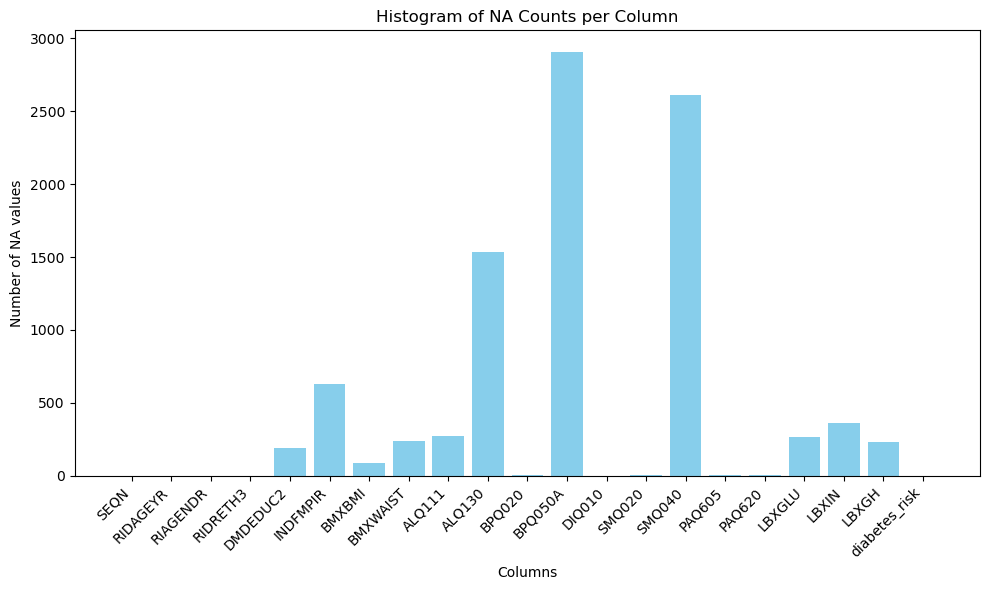

,NA_Count,NA_Percent
BPQ050A,2909,65.547544
SMQ040,2610,58.810275
ALQ130,1535,34.587652
INDFMPIR,630,14.195584
LBXIN,359,8.089229
ALQ111,273,6.151420
LBXGLU,265,5.971158
BMXWAIST,237,5.340243
LBXGH,234,5.272645
DMDEDUC2,189,4.258675


In [12]:
na_counts = data.isna().sum()
na_percent = na_counts / len(data) * 100
na_df = pd.DataFrame({'NA_Count': na_counts, 'NA_Percent': na_percent})

# Plot histogram of NA counts
plt.figure(figsize=(10, 6))
plt.bar(na_df.index, na_df['NA_Count'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Columns')
plt.ylabel('Number of NA values')
plt.title('Histogram of NA Counts per Column')
plt.tight_layout()
plt.show()

missing_summary = pd.DataFrame({
    'NA_Count': na_counts,
    'NA_Percent': na_percent
})
missing_summary.sort_values(by='NA_Count', ascending=False)

# Variable Analysis

In [13]:
labels = {
    # --- Demographics ---
    "SEQN": "Sequence Number",
    "RIDAGEYR": "Age (years)",
    "RIAGENDR": "Gender (1=Male, 2=Female)",
    "RIDRETH3": "Race/Ethnicity",
    "DMDEDUC2": "Education level (Adults 20+)",
    "INDFMPIR": "Income-to-poverty ratio",

    # --- Behaviors ---
    "SMQ020": "Smoked ≥100 cigarettes in life (1=Yes, 2=No)",
    "SMQ040": "Current smoking status",
    "ALQ111": "Ever had a drink of alcohol (1=Yes, 2=No)",
    "ALQ130": "Average # of alcoholic drinks/day (past 12 months)",
    "PAQ605": "Vigorous work activity (1=Yes, 2=No)",
    "PAQ620": "Moderate work activity (1=Yes, 2=No)",

    # --- Biomarkers ---
    "BMXBMI": "Body Mass Index (kg/m²)",
    "BMXWAIST": "Waist circumference (cm)",
    "SBP": "Average Systolic Blood Pressure (mmHg)",
    "LBXGLU": "Fasting Glucose (mg/dL)",
    "LBXIN": "Insulin (μU/mL)",
    "LBXGH": "Glycohemoglobin (HbA1c, %)",

    # --- Outcomes ---
    "BPQ020": "Ever told had high blood pressure",
    "BPQ050A": "Taking prescribed medicine for hypertension",
    "DIQ010": "Doctor told you have diabetes",

    # --- Derived ---
    "diabetes_risk": "Derived diabetes risk (0=No risk, 1=Risk, 2=Missing)"
}

In [14]:
continuous_vars = ['RIDAGEYR', 'INDFMPIR', 'BMXBMI', 'BMXWAIST', 'ALQ130', 'LBXGLU', 'LBXIN', 'LBXGH']
categorical_vars = ['RIAGENDR', 'RIDRETH3', 'DMDEDUC2', 'ALQ111', 'BPQ020', 'BPQ050A', 'DIQ010', 'SMQ020', 'SMQ040', 'PAQ605', 'PAQ620', 'diabetes_risk']
variables = continuous_vars + categorical_vars

# Univariate Analysis

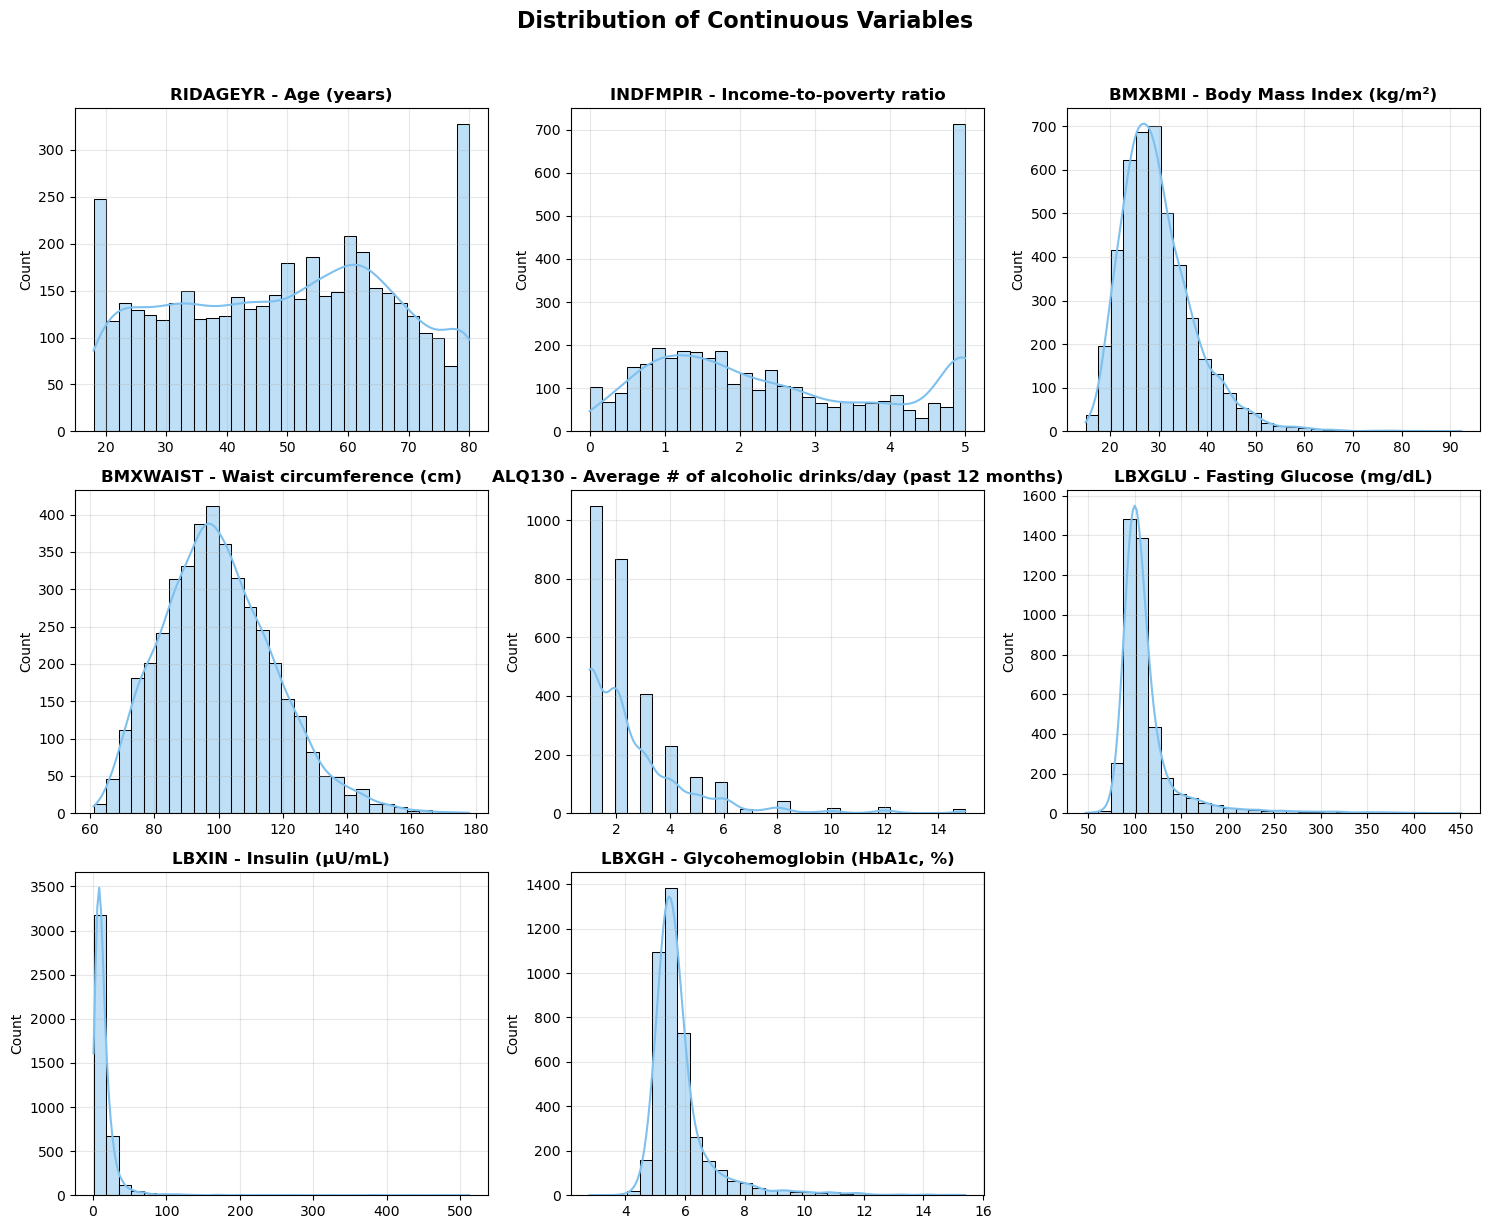


Summary Statistics for Continuous Variables:



,count,min,Q1,Q2 (Median),Q3,max,mean,Std. Dev.,median
RIDAGEYR,4438.0,18.00,34.00,51.00,64.000,80.0,49.629,18.292,51.00
INDFMPIR,3808.0,0.00,1.18,2.19,4.080,5.0,2.556,1.615,2.19
BMXBMI,4348.0,14.90,24.60,28.50,33.600,92.3,29.813,7.721,28.50
BMXWAIST,4201.0,61.10,87.50,98.70,111.200,178.0,100.174,17.473,98.70
ALQ130,2903.0,1.00,1.00,2.00,3.000,15.0,2.527,2.058,2.00
LBXGLU,4173.0,47.00,95.00,103.00,114.000,451.0,112.913,37.526,103.00
LBXIN,4079.0,0.71,6.17,10.01,16.565,512.5,15.032,23.964,10.01
LBXGH,4204.0,2.80,5.30,5.60,6.000,15.4,5.851,1.136,5.60


In [15]:
def plot_univariate_summary(df, continuous_vars, bins=30, color="#7EC0EE"):
    """
    Plot histograms for multiple continuous variables and print summary statistics.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset containing the variables.
    continuous_vars : list of str
        List of continuous variable names.
    bins : int, optional
        Number of bins for histograms.
    color : str, optional
        Color of histogram bars.
    """

    # Filter available variables
    vars_available = [v for v in continuous_vars if v in df.columns]
    n = len(vars_available)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    # ---- Plot histograms ----
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4*nrows))
    axes = axes.flatten()

    for i, var in enumerate(vars_available):
        sns.histplot(df[var].dropna(), bins=bins, kde=True, color=color, ax=axes[i])
        axes[i].set_title(f"{var} - {labels[var]}", fontsize=12, weight="bold")
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Count")
        axes[i].grid(alpha=0.3)

    # Hide empty subplots
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle("Distribution of Continuous Variables", fontsize=16, weight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    # ---- Summary statistics ----
    summary = df[vars_available].describe().T
    summary["median"] = df[vars_available].median()
    summary = summary[["count", "min", "25%", "50%", "75%", "max", "mean", "std", "median"]]
    summary = summary.rename(columns={
        "50%": "Q2 (Median)", "25%": "Q1", "75%": "Q3", "std": "Std. Dev."
    })

    print("\nSummary Statistics for Continuous Variables:\n")
    display(summary.round(3))

    return summary

summary_stats = plot_univariate_summary(data, continuous_vars)

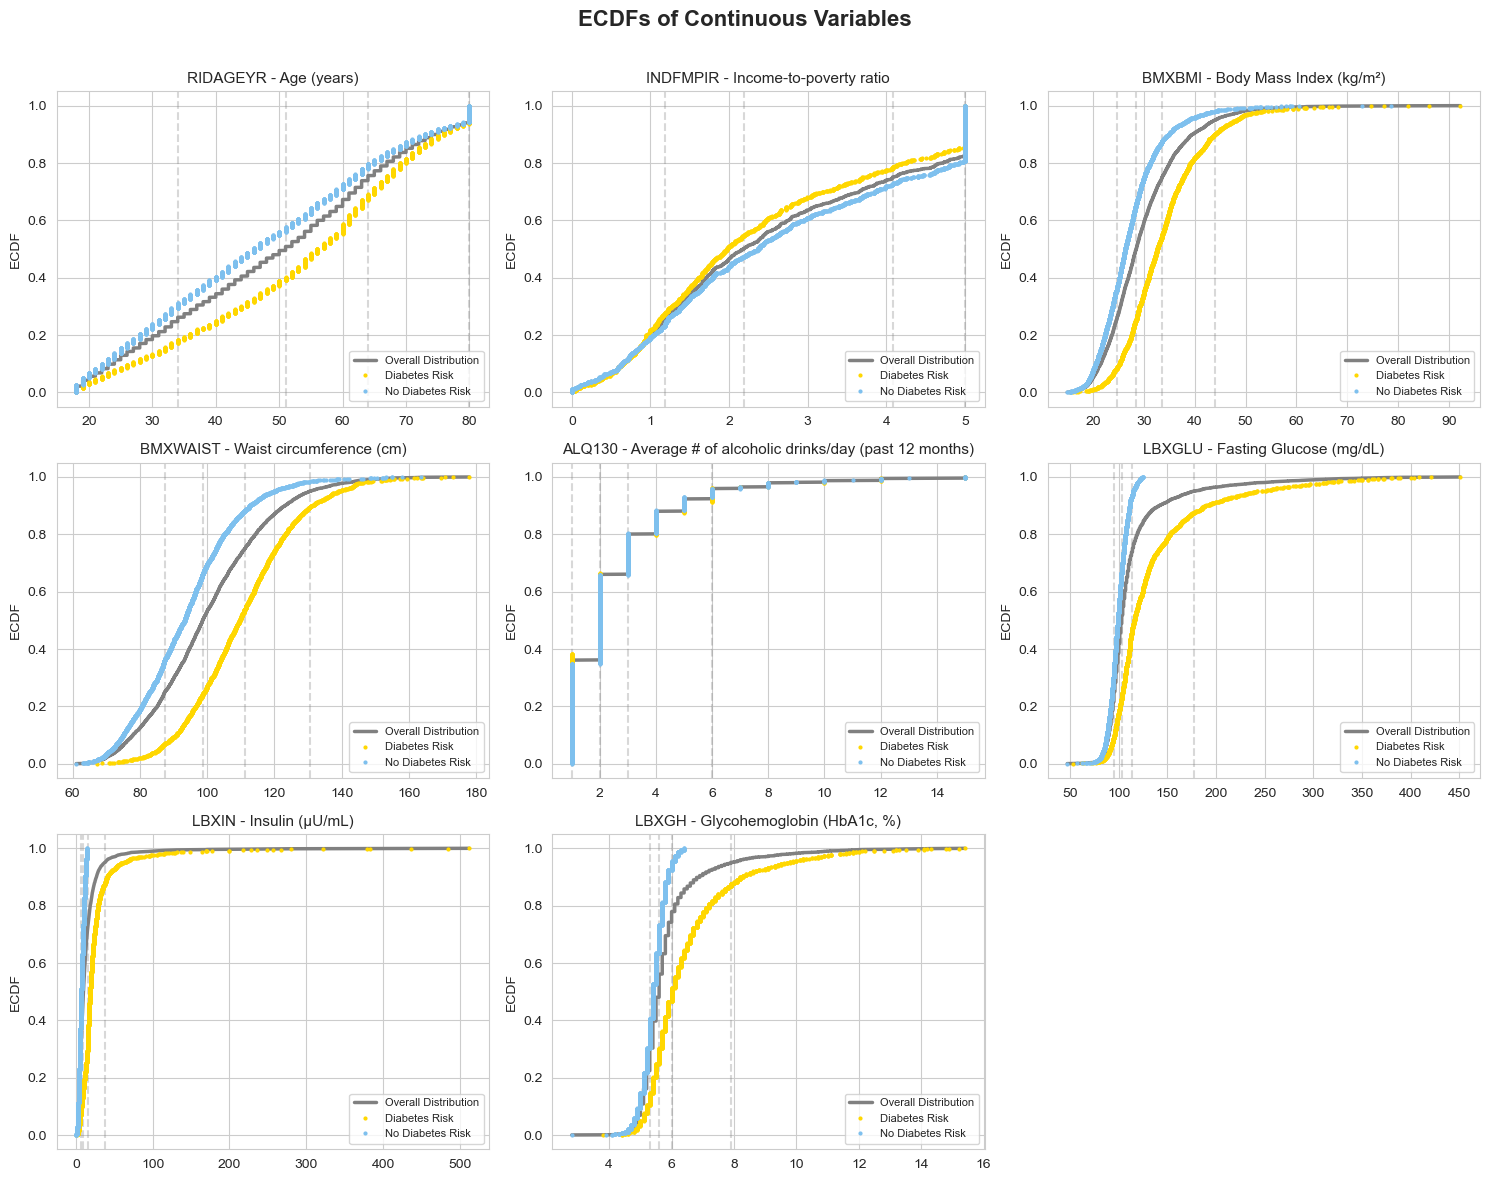

In [16]:
def plot_ecdf_grid(df, variables, group_col='diabetes_risk', colors=None, cols=3):
    """
    Plot ECDFs for multiple continuous variables in a grid layout.
    
    Parameters
    ----------
    df : pd.DataFrame
        The dataset.
    variables : list of str
        Continuous variables to plot.
    group_col : str
        Column used to separate groups (default: 'diabetes_risk').
    colors : dict
        Optional dict mapping group labels to colors.
    cols : int
        Number of columns in the subplot grid.
    """
    
    if colors is None:
        colors = {
            'Diabetes Risk': '#FFD700',
            'No Diabetes Risk': '#7EC0EE',
        }
    
    sns.set_style("whitegrid")
    plt.rcParams.update({"axes.labelsize": 10, "axes.titlesize": 11})
    
    n_vars = len(variables)
    rows = (n_vars + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten()
    
    for i, var in enumerate(variables):
        ax = axes[i]
        # Overall ECDF
        x_all = np.sort(df[var].dropna())
        y_all = np.arange(1, len(x_all) + 1) / len(x_all)
        ax.plot(x_all, y_all, color='gray', linewidth=2.5, label='Overall Distribution')
        
        # Quantiles
        quantiles = [25, 50, 75, 95]
        q_values = np.percentile(x_all, quantiles)
        for q, q_val in zip(quantiles, q_values):
            ax.axvline(q_val, linestyle='--', color='gray', alpha=0.3)
        
        # By group
        for g in df[group_col].dropna().unique():
            if g not in colors: 
                continue
            subset = df[df[group_col] == g][var].dropna()
            if subset.empty:
                continue
            x = np.sort(subset)
            y = np.arange(1, len(x) + 1) / len(x)
            ax.plot(x, y, '.', markersize=4, color=colors[g], label=g)
        
        ax.set_title(f"{var} - {labels[var]}")
        ax.set_xlabel("")
        ax.set_ylabel("ECDF")
        ax.legend(frameon=True, loc='lower right', fontsize=8)
    
    # Hide unused axes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    fig.suptitle("ECDFs of Continuous Variables", fontsize=16, weight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

plot_ecdf_grid(data, continuous_vars)

## Detecting outliers

In [17]:

def check_outliers_iqr(df, continuous_vars):
    """
    Detect outliers in multiple continuous variables using the IQR rule.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset containing variables.
    continuous_vars : list of str
        Names of continuous variables to check.

    Returns
    -------
    pd.DataFrame
        Summary table with outlier statistics per variable.
    """

    results = []

    for var in continuous_vars:
        series = df[var].dropna()
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = series[(series < lower_bound) | (series > upper_bound)]
        outlier_count = len(outliers)
        total = len(series)
        outlier_pct = (outlier_count / total) * 100 if total > 0 else np.nan

        results.append({
            "Variable": var,
            "Count": total,
            "Q1": round(Q1, 2),
            "Q3": round(Q3, 2),
            "IQR": round(IQR, 2),
            "Lower_Bound": round(lower_bound, 2),
            "Upper_Bound": round(upper_bound, 2),
            "Outliers": outlier_count,
            "Outlier_%": round(outlier_pct, 2),
            "Min": round(series.min(), 2),
            "Max": round(series.max(), 2)
        })

    summary = pd.DataFrame(results)
    summary = summary.sort_values(by="Outlier_%", ascending=False).reset_index(drop=True)

    print("🔍 Outlier Summary (IQR Rule)")
    print(summary)
    return summary

outlier_summary = check_outliers_iqr(data, continuous_vars)

🔍 Outlier Summary (IQR Rule)
   Variable  Count     Q1      Q3    IQR  Lower_Bound  Upper_Bound  Outliers  \
0    LBXGLU   4173  95.00  114.00  19.00        66.50       142.50       420   
1     LBXGH   4204   5.30    6.00   0.70         4.25         7.05       380   
2     LBXIN   4079   6.17   16.56  10.39        -9.42        32.16       267   
3    ALQ130   2903   1.00    3.00   2.00        -2.00         6.00       117   
4    BMXBMI   4348  24.60   33.60   9.00        11.10        47.10       133   
5  BMXWAIST   4201  87.50  111.20  23.70        51.95       146.75        45   
6  RIDAGEYR   4438  34.00   64.00  30.00       -11.00       109.00         0   
7  INDFMPIR   3808   1.18    4.08   2.90        -3.17         8.43         0   

   Outlier_%    Min    Max  
0      10.06  47.00  451.0  
1       9.04   2.80   15.4  
2       6.55   0.71  512.5  
3       4.03   1.00   15.0  
4       3.06  14.90   92.3  
5       1.07  61.10  178.0  
6       0.00  18.00   80.0  
7       0.00   0.0

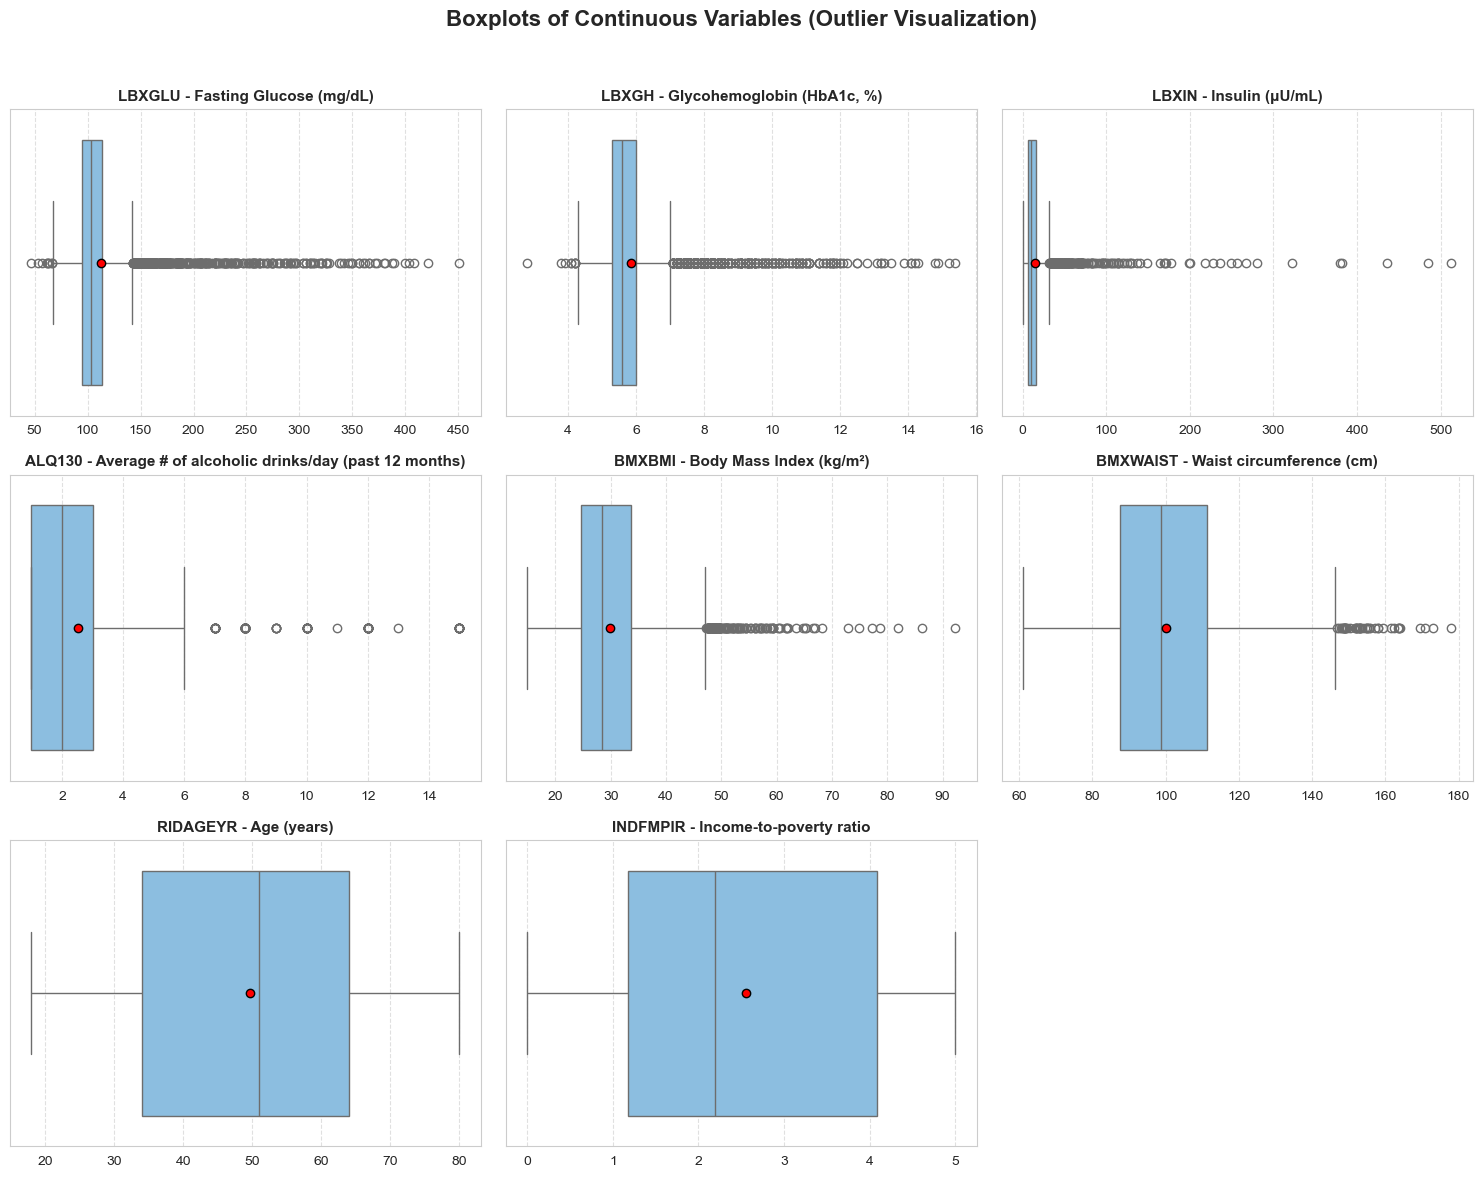

In [18]:
def plot_boxplots(df, continuous_vars):
    """
    Plot boxplots for all continuous variables to visualize outliers.
    """
    n = len(continuous_vars)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten()
    
    sns.set(style="whitegrid")

    for i, var in enumerate(continuous_vars):
        sns.boxplot(data=df, x=var, ax=axes[i], color="#7EC0EE", showmeans=True,
                    meanprops={"marker":"o", "markerfacecolor":"red", "markeredgecolor":"black"})
        axes[i].set_title(f"{var} - {labels[var]}", fontsize=11, fontweight="bold")
        axes[i].set_xlabel("")
        axes[i].grid(axis="x", linestyle="--", alpha=0.6)

    # Hide any unused axes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle("Boxplots of Continuous Variables (Outlier Visualization)", fontsize=16, weight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

continuous_vars_order_by_outliers = outlier_summary['Variable'].tolist()
plot_boxplots(data, continuous_vars_order_by_outliers)

## Categorical Variables

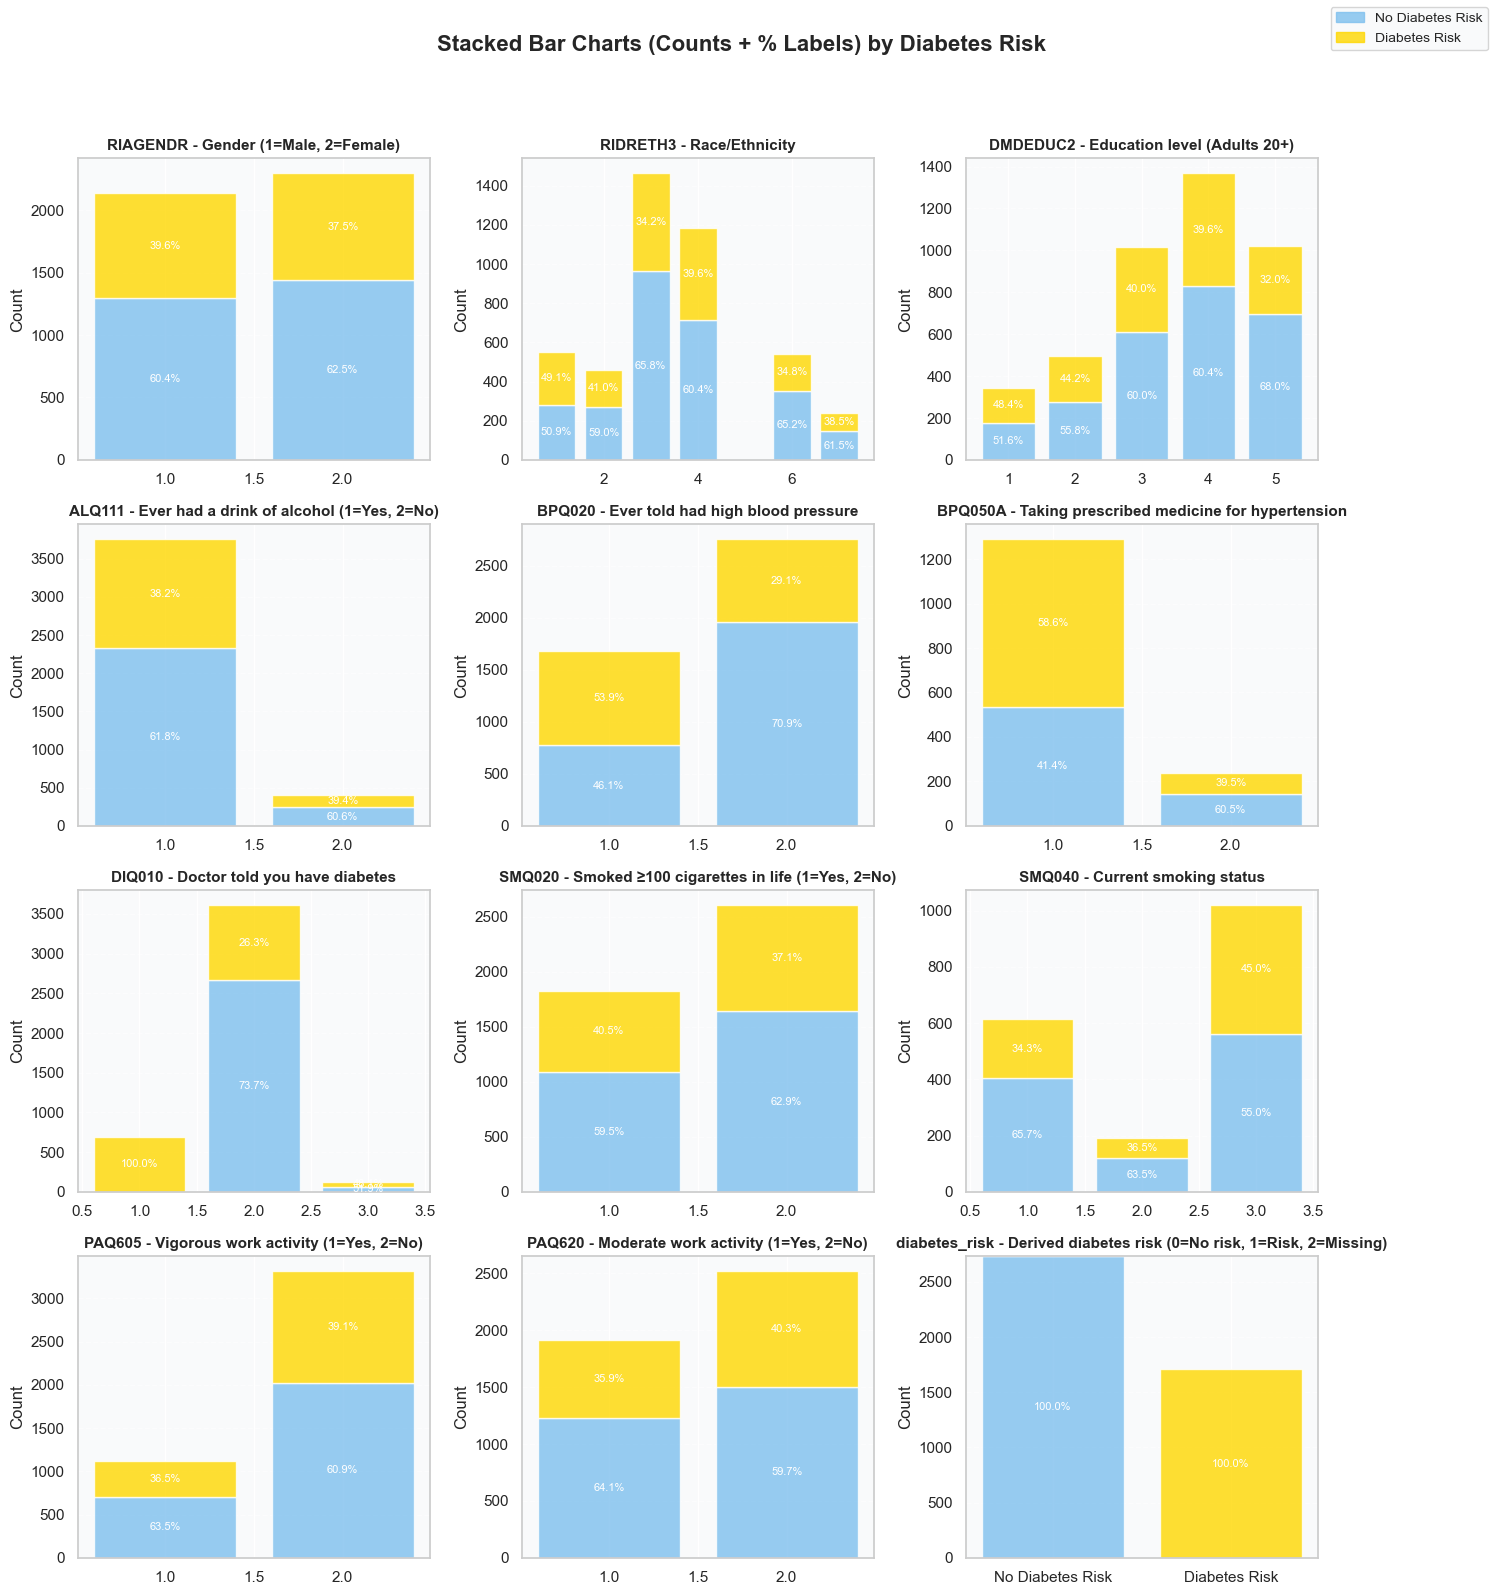

In [19]:


def plot_stacked_bars_count(df, categorical_vars, target):
    """
    Plot stacked bar charts (raw counts) with % labels inside each stack segment.
    """
    colors = ['#7EC0EE', '#FFD700']  # Blue = No Diabetes, Yellow = Diabetes
    sns.set(style="whitegrid", rc={"axes.facecolor": "#F8F9FA", "grid.color": "white"})
    
    n = len(categorical_vars)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten()
    
    for i, var in enumerate(categorical_vars):
        ctab = pd.crosstab(df[var], df[target])
        
        # Plot stacked bars
        bottom_values = np.zeros(len(ctab))
        for j, col in enumerate(ctab.columns):
            axes[i].bar(ctab.index, ctab[col], bottom=bottom_values,
                        color=colors[j % len(colors)], alpha=0.8)
            
            # Compute percentages for labels
            total_per_cat = ctab.sum(axis=1)
            percents = (ctab[col] / total_per_cat * 100).round(1)
            
            # Add text labels centered in each segment
            for k, (x, y, p) in enumerate(zip(ctab.index, bottom_values, percents)):
                height = ctab.iloc[k, j]
                if height > 0:
                    axes[i].text(x, y + height / 2, f"{p:.1f}%", 
                                 ha='center', va='center', fontsize=8, color='white')
            bottom_values += ctab[col].values
        
        axes[i].set_title(f"{var} - {labels[var]}", fontsize=11, fontweight="bold")
        axes[i].set_ylabel("Count")
        axes[i].grid(axis="y", linestyle="--", alpha=0.5)
        axes[i].set_facecolor("#F9FAFB")
    
    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    # Legend
    handles = [
        plt.Rectangle((0, 0), 1, 1, color=colors[0], alpha=0.8, label='No Diabetes Risk'),
        plt.Rectangle((0, 0), 1, 1, color=colors[1], alpha=0.8, label='Diabetes Risk')
    ]
    fig.legend(handles=handles, loc="upper right", fontsize=10)
    
    fig.suptitle("Stacked Bar Charts (Counts + % Labels) by Diabetes Risk",
                 fontsize=16, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    plt.show()
plot_stacked_bars_count(data, categorical_vars, 'diabetes_risk')

# Bivariate Analysis

## Discarded: For Continuous - Continuous

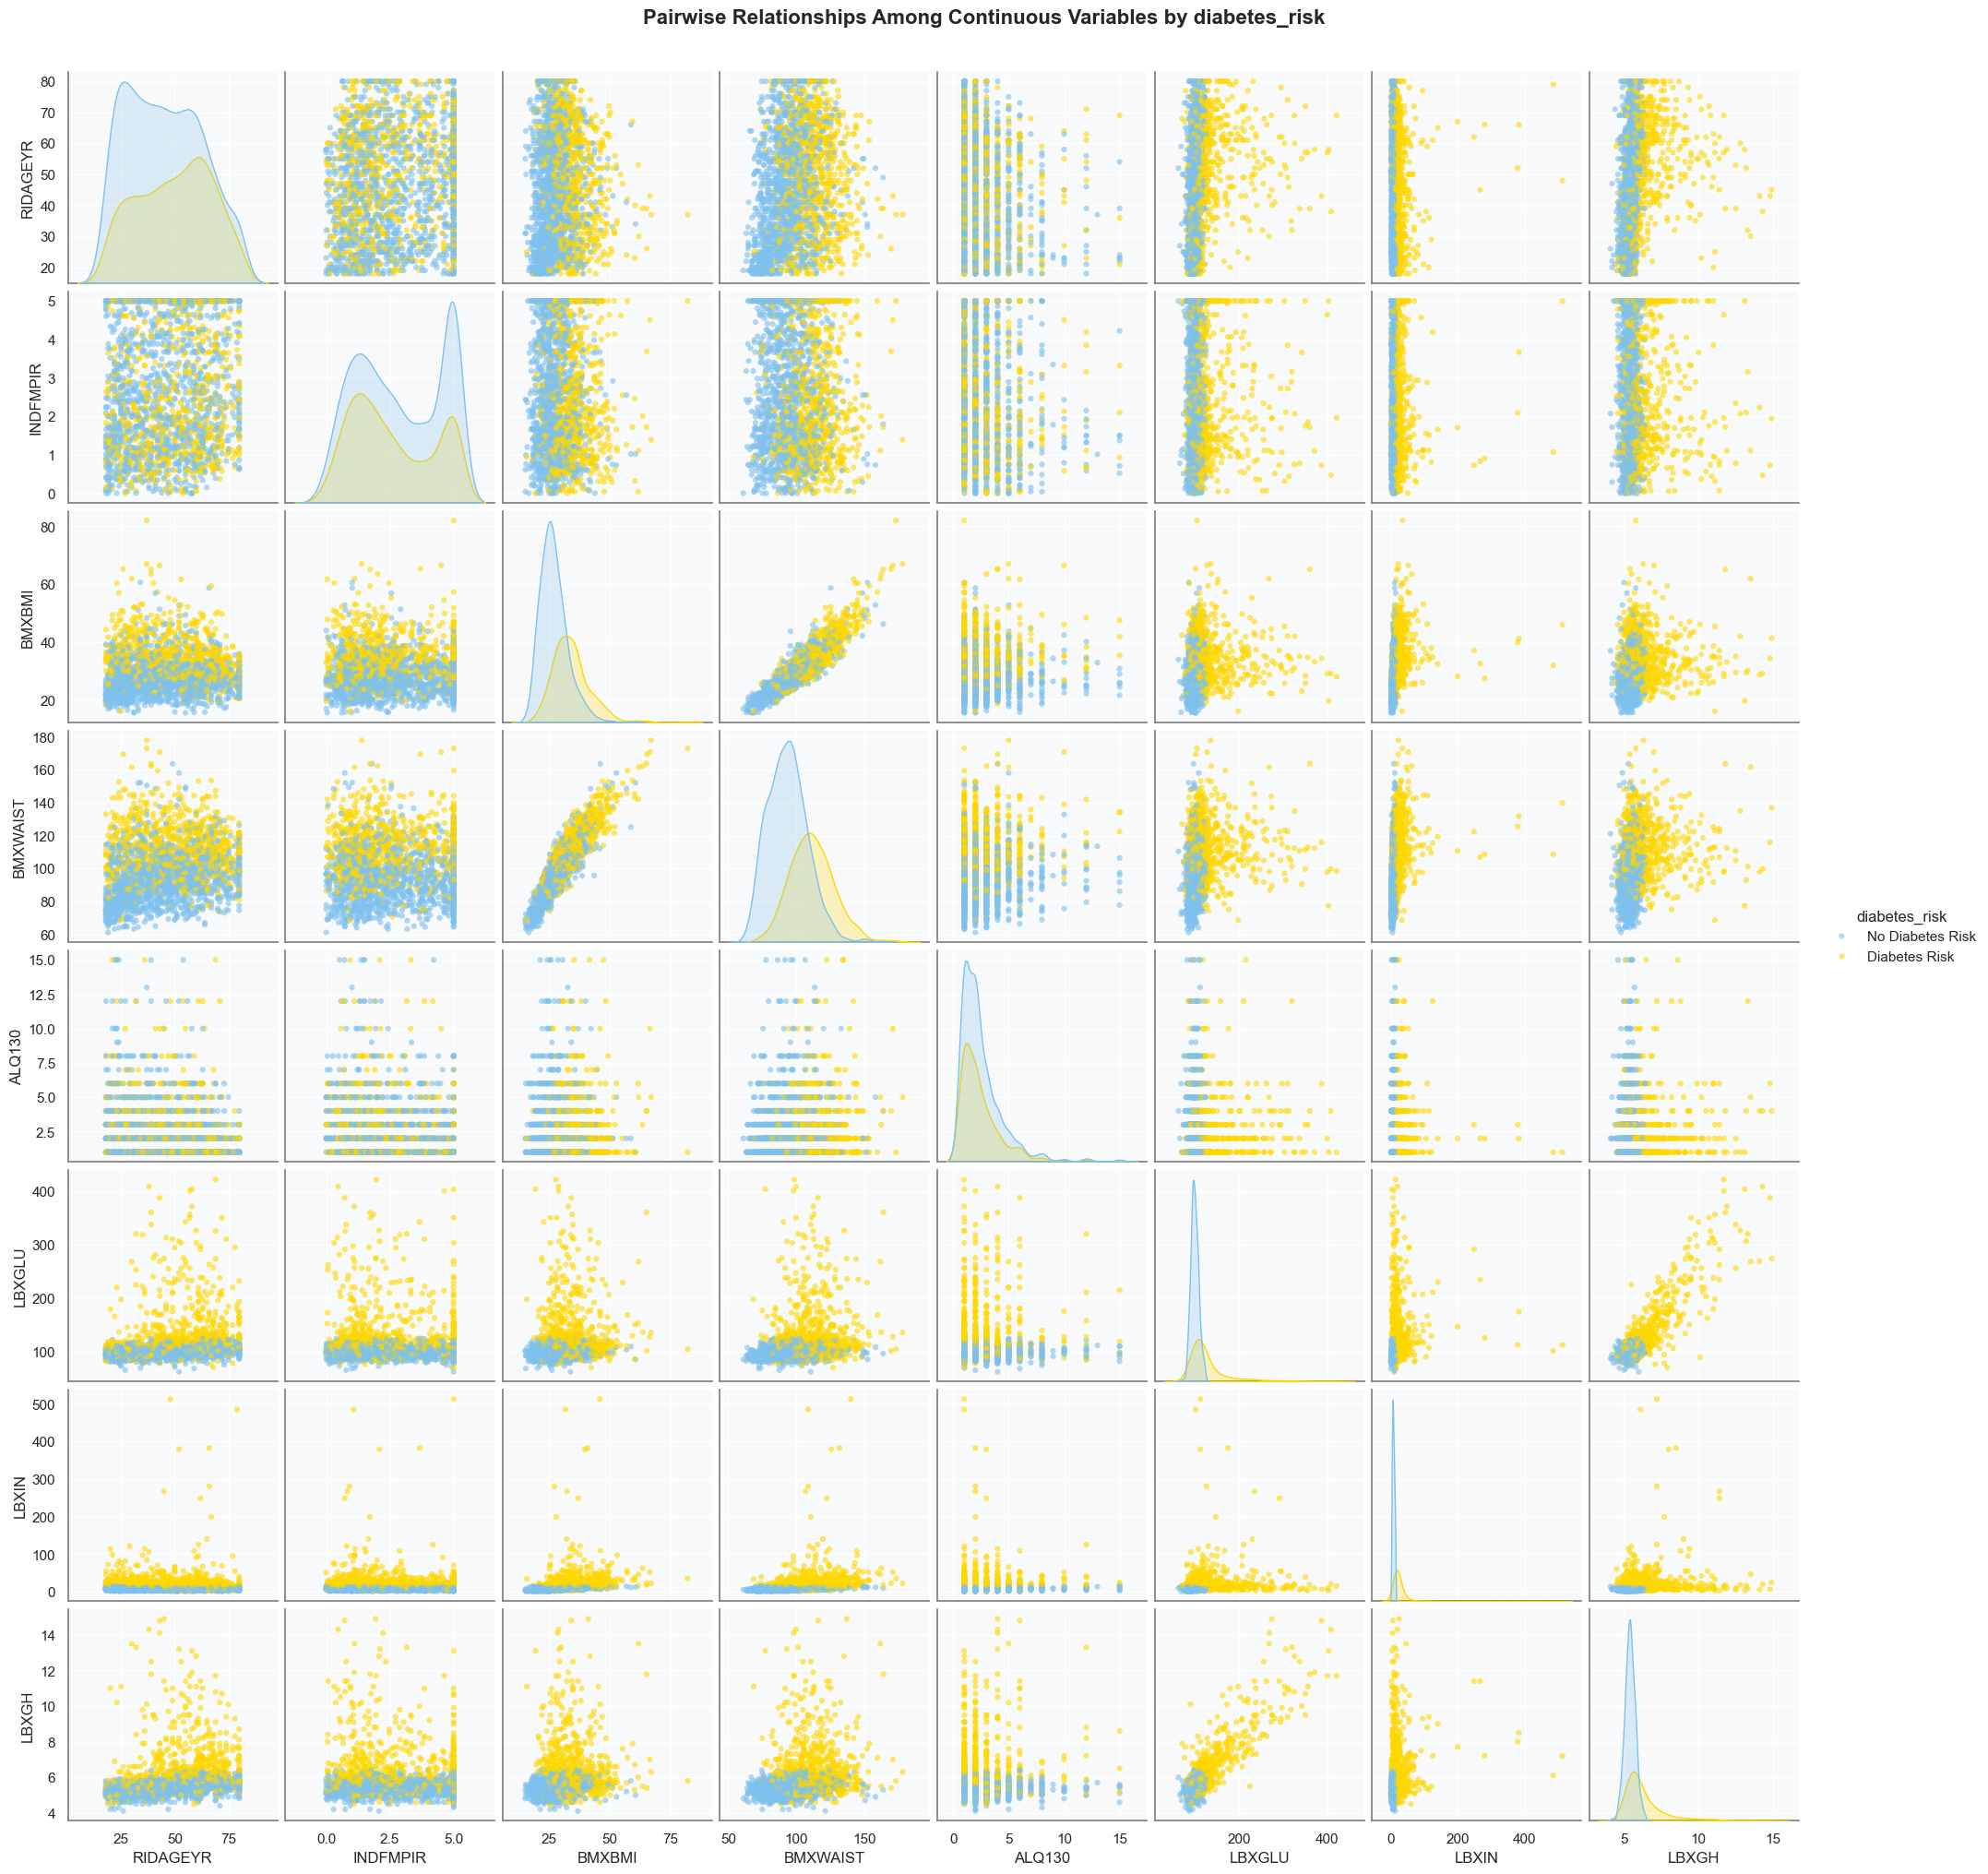

In [20]:
def plot_continuous_pairplot(df, continuous_vars, hue=None):
    """
    Plot a pairplot (scatter + hist) for continuous variables, optionally colored by hue.
    """
    sns.set(style="whitegrid", rc={
        "axes.facecolor": "#F8F9FA",
        "grid.color": "white",
        "axes.edgecolor": "0.5"
    })
    
    # Use soft, Plotly-like colors
    palette = {"No Diabetes Risk": "#7EC0EE", "Diabetes Risk": "#FFD700"}
    
    # Map hue values to readable labels if needed
    if hue and df[hue].dtype.name != 'category':
        df[hue] = df[hue].replace({
            0: "No Diabetes Risk",
            1: "Diabetes Risk",
            2: "Missing Data"
        }).astype("category")
    
    # Subset for continuous vars
    plot_df = df[continuous_vars + ([hue] if hue else [])].dropna()
    
    # Create pairplot
    g = sns.pairplot(
        plot_df,
        vars=continuous_vars,
        hue=hue,
        palette=palette if hue else "Set2",
        diag_kind="kde",
        corner=False,
        plot_kws={'alpha': 0.6, 's': 20, 'edgecolor': 'none'}
    )
    
    g.figure.suptitle(
        "Pairwise Relationships Among Continuous Variables" + (f" by {hue}" if hue else ""),
        fontsize=16, fontweight="bold", y=1.02
    )
    plt.show()
plot_continuous_pairplot(data, continuous_vars, hue='diabetes_risk')

## Correlation Heatmap (Pearson)
Can you include categorical variables in a correlation heatmap?

➡️ Not directly, because:
	•	Correlation (Pearson, Spearman, etc.) only applies to numeric values.
	•	Categorical features like Gender, Education, or Race don’t have a natural numeric order or distance.

However — there are workarounds depending on what you want to measure
1. Encode categorical variables → numeric

If your categorical variables are ordinal (have a natural order), you can map them to numbers and include them:
✅ Good examples:
	•	DMDEDUC2 (education level)
	•	PAQ620 (moderate work activity yes/no)
	•	SMQ020 (smoked ≥100 cigs yes/no)

❌ Bad examples:
	•	RIDRETH3 (ethnicity) — categories are nominal (unordered).



In [21]:
correlation_vars = continuous_vars + ['DMDEDUC2', 'ALQ111', 'BPQ020', 'DIQ010', 'SMQ020', 'PAQ605']

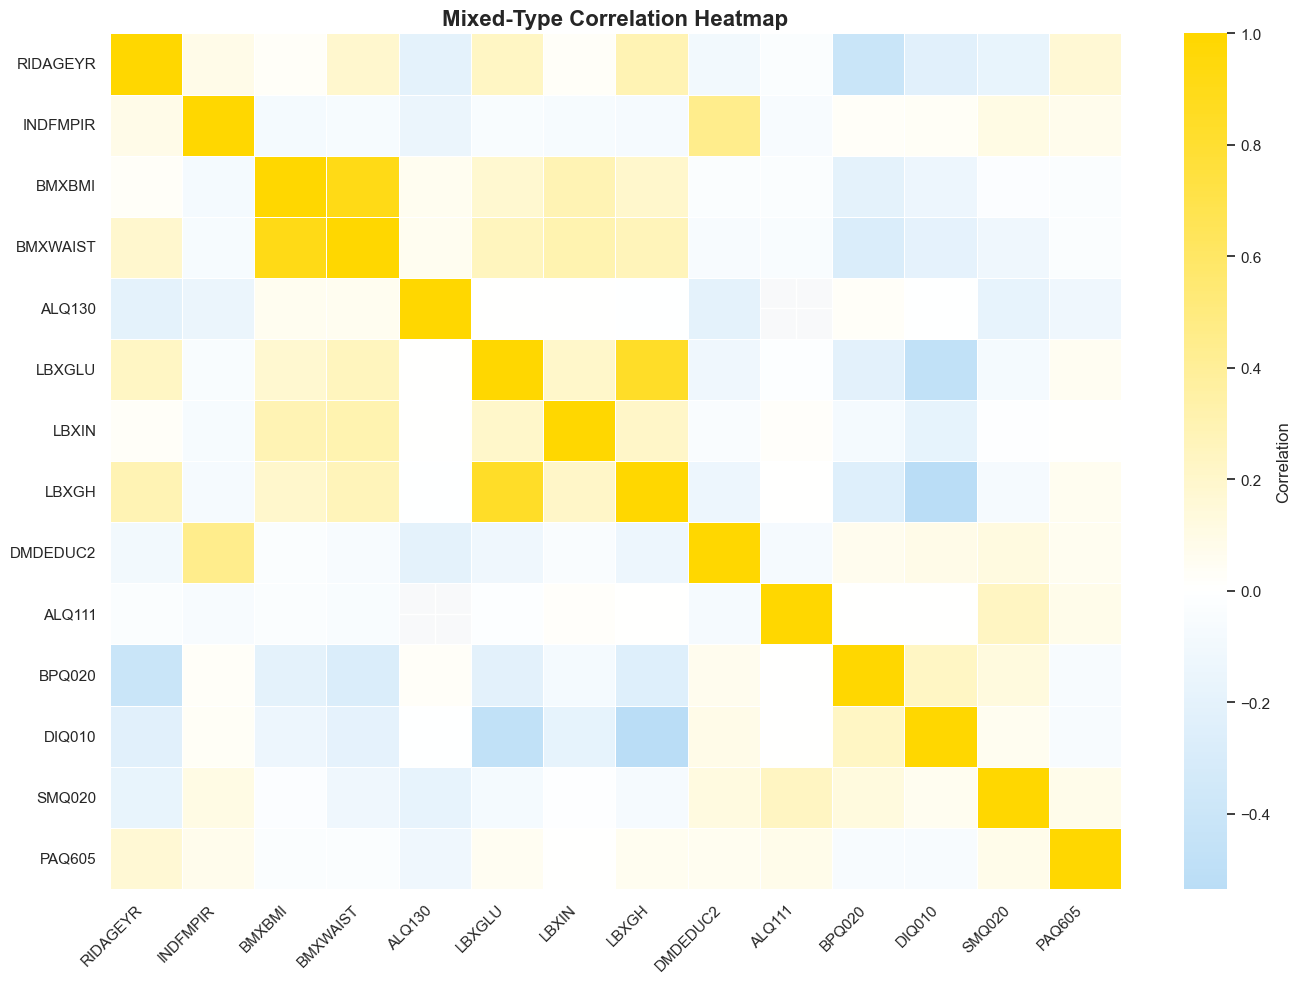

Top 10 Absolute Correlations (Unique Pairs):
  BMXBMI × BMXWAIST = 0.909
  LBXGLU × LBXGH = 0.836
  LBXGH × DIQ010 = -0.535
  LBXGLU × DIQ010 = -0.480
  INDFMPIR × DMDEDUC2 = 0.444
  RIDAGEYR × BPQ020 = -0.419
  BMXWAIST × LBXIN = 0.306
  BMXBMI × LBXIN = 0.298
  RIDAGEYR × LBXGH = 0.288
  BMXWAIST × BPQ020 = -0.278


In [22]:
def plot_mixed_correlation_heatmap(df, continuous_vars, categorical_vars, method="pearson"):
    # Encode categorical variables
    df_encoded = pd.get_dummies(df[categorical_vars], drop_first=True)
    df_num = pd.concat([df[continuous_vars], df_encoded], axis=1)

    # Compute correlation
    corr = df_num.corr(method=method)

    # Continuous colormap from blue → white → yellow
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "blue_white_yellow",
        ["#7EC0EE", "#FFFFFF", "#FFD700"],  # soft blue → white → yellow
        N=256  # increase number of levels for smoothness
)

    # Plot
    plt.figure(figsize=(14, 10))
    sns.heatmap(
        corr,
        cmap=sns.color_palette("blend:#7EC0EE,#FFFFFF,#FFD700", as_cmap=True),
        center=0,
        linewidths=0.4,
        cbar_kws={'label': 'Correlation'},
    )
    plt.title("Mixed-Type Correlation Heatmap", fontsize=16, weight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # Print top correlations (unique pairs only)
    corr_unstacked = (
        corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))  # keep upper triangle
        .stack()
        .reset_index()
        .rename(columns={'level_0': 'Var1', 'level_1': 'Var2', 0: 'Correlation'})
    )
    corr_unstacked["AbsCorr"] = corr_unstacked["Correlation"].abs()
    top_corr = corr_unstacked.sort_values("AbsCorr", ascending=False).head(10)

    # Display results
    print("Top 10 Absolute Correlations (Unique Pairs):")
    for _, row in top_corr.iterrows():
        print(f"  {row['Var1']} × {row['Var2']} = {row['Correlation']:.3f}")
plot_mixed_correlation_heatmap(data, continuous_vars, ['DMDEDUC2', 'ALQ111', 'BPQ020', 'DIQ010', 'SMQ020', 'PAQ605'], method="pearson")

## T-test and nonparametric tests
Test if group means differ significantly
| **Condition**           | **Recommended Test**                    |
|--------------------------|----------------------------------------|
| Normal, equal variance   | t-test                                 |
| Skewed / non-normal      | Mann–Whitney U                         |
| > 2 groups, normal       | ANOVA                                  |
| > 2 groups, skewed       | Kruskal–Wallis                         |
| Ordinal / ranks          | Nonparametric (Mann–Whitney or Kruskal) |

In [23]:
def check_normality_by_group(df, group_col, cont_vars, alpha=0.05):
    """
    Tests normality (Shapiro–Wilk) for each continuous variable within each group.
    
    Parameters
    ----------
    df : pd.DataFrame
        Your dataset
    group_col : str
        The name of the categorical grouping column (e.g., 'diabetes_risk')
    cont_vars : list
        List of continuous variable names to test
    alpha : float
        Significance level (default = 0.05)
    
    Returns
    -------
    pd.DataFrame
        Table summarizing normality test results for each group-variable combination.
    """

    results = []
    groups = df[group_col].dropna().unique()

    for var in cont_vars:
        for g in groups:
            subset = df.loc[df[group_col] == g, var].dropna()

            # Only test if at least 3 non-null values exist
            if len(subset) < 3:
                results.append({
                    "Variable": var,
                    "Group": g,
                    "N": len(subset),
                    "W-statistic": None,
                    "p-value": None,
                    "Normal?": "Too few samples"
                })
                continue

            # Shapiro-Wilk test
            stat, p = shapiro(subset)
            results.append({
                "Variable": var,
                "Group": g,
                "N": len(subset),
                "W-statistic": stat,
                "p-value": p,
                "Normal?": "Yes" if p > alpha else "No"
            })

    results_df = pd.DataFrame(results)
    return results_df
normality_results = check_normality_by_group(data, 'diabetes_risk', continuous_vars)
print(normality_results)

    Variable             Group     N  W-statistic       p-value Normal?
0   RIDAGEYR     Diabetes Risk  1708     0.955268  1.838197e-22      No
1   RIDAGEYR  No Diabetes Risk  2730     0.955351  3.863882e-28      No
2   INDFMPIR     Diabetes Risk  1462     0.903862  2.286147e-29      No
3   INDFMPIR  No Diabetes Risk  2346     0.903616  3.957915e-36      No
4     BMXBMI     Diabetes Risk  1672     0.923814  2.708422e-28      No
5     BMXBMI  No Diabetes Risk  2676     0.909744  3.303617e-37      No
6   BMXWAIST     Diabetes Risk  1605     0.990339  8.140815e-09      No
7   BMXWAIST  No Diabetes Risk  2596     0.976098  1.863761e-20      No
8     ALQ130     Diabetes Risk  1023     0.702442  4.319465e-39      No
9     ALQ130  No Diabetes Risk  1880     0.708022  3.351039e-49      No
10    LBXGLU     Diabetes Risk  1671     0.722674  2.917131e-46      No
11    LBXGLU  No Diabetes Risk  2502     0.991330  4.078509e-11      No
12     LBXIN     Diabetes Risk  1648     0.408777  1.194280e-58 

### They are all non-normal => Mann-Whitney U

In [24]:
def mann_whitney_by_group(df, group_col, cont_vars):
    results = []
    groups = df[group_col].dropna().unique()
    if len(groups) != 2:
        print(f"{group_col} must have exactly 2 groups.")
        return

    g1, g2 = groups
    for var in cont_vars:
        data1 = df.loc[df[group_col]==g1, var].dropna()
        data2 = df.loc[df[group_col]==g2, var].dropna()
        stat, p = mannwhitneyu(data1, data2, alternative="two-sided")
         # Add significance stars or thresholds
        if p < 0.001:
            sig = "*** (p < 0.001)"
        elif p < 0.01:
            sig = "** (p < 0.01)"
        elif p < 0.05:
            sig = "* (p < 0.05)"
        else:
            sig = "ns (not significant)"
        
        results.append({
            "Variable": var,
            "Median_Group1": data1.median(),
            "Median_Group2": data2.median(),
            "Statistic": round(stat, 2),
            "p-value": p,
            "Significance": sig
        })
    return pd.DataFrame(results)
mw_results = mann_whitney_by_group(data, 'diabetes_risk', continuous_vars)
print(mw_results)

   Variable  Median_Group1  Median_Group2  Statistic        p-value  \
0  RIDAGEYR         56.000          46.00  2814499.5   2.755483e-31   
1  INDFMPIR          1.970           2.37  1581072.5   4.743120e-05   
2    BMXBMI         32.600          26.30  3421035.0  5.411692e-190   
3  BMXWAIST        109.800          93.35  3257391.5  1.755243e-207   
4    ALQ130          2.000           2.00   940802.5   3.151160e-01   
5    LBXGLU        116.000          99.00  3389128.0  2.368050e-254   
6     LBXIN         18.675           7.35  3575772.0   0.000000e+00   
7     LBXGH          6.000           5.40  3332853.0  5.106222e-219   

           Significance  
0       *** (p < 0.001)  
1       *** (p < 0.001)  
2       *** (p < 0.001)  
3       *** (p < 0.001)  
4  ns (not significant)  
5       *** (p < 0.001)  
6       *** (p < 0.001)  
7       *** (p < 0.001)  


- 1.	Metabolic markers (glucose, insulin, HbA1c, BMI, waist) are dramatically higher in the diabetes-risk group (p < 0.001 across all.

This strongly supports that your constructed diabetes_risk variable successfully distinguishes individuals with metabolic dysregulation.

- 2.	Age is significantly higher in the diabetes-risk group.

Age is a known risk factor — older participants are more likely to develop diabetes.

- 3.	Income-to-poverty ratio is lower among diabetes-risk individuals.

Suggests socioeconomic disparities in diabetes prevalence.

- 4.	Alcohol use (ALQ130) shows no significant difference.

Drinking frequency or volume may not be directly associated with diabetes risk in this sample (or the variable may not capture relevant consumption patterns).

## For Categorical-Categorical

###  Cross-tabulations

In [25]:
def cross_tab_summary(df, var1, var2, normalize=False, show_chi2=True):
    """
    Generate a cross-tabulation table between two categorical variables,
    with optional normalization and Chi-square test of independence.
    
    Parameters
    ----------
    df : pd.DataFrame
        Your dataset
    var1, var2 : str
        The two categorical variables to cross-tabulate
    normalize : bool
        If True, normalize counts to proportions (within rows)
    show_chi2 : bool
        If True, perform Chi-square test and print results
    
    Returns
    -------
    pd.DataFrame
        Cross-tabulation table (counts or proportions)
    """
    # Cross-tab table
    ctab = pd.crosstab(df[var1], df[var2], normalize='index' if normalize else False)
    ctab_display = ctab * 100 if normalize else ctab
    display(ctab_display.round(2))

    if show_chi2:
        chi2, p, dof, expected = chi2_contingency(pd.crosstab(df[var1], df[var2]))
        print(f"\n🔍 Chi-square test of independence between '{var1}' and '{var2}':")
        print(f"  χ² = {chi2:.3f}, df = {dof}, p = {p:.4e}")
        if p < 0.05:
            print("  ➤ Significant association detected (reject H₀)")
        else:
            print("  ➤ No significant association (fail to reject H₀)")

    # return ctab_display

In [26]:
for var in categorical_vars:
    if var != 'diabetes_risk':
        print(f"\nCross-tabulation: {var} vs. diabetes_risk")
        cross_tab_summary(data, var, 'diabetes_risk', normalize=True, show_chi2=True)


Cross-tabulation: RIAGENDR vs. diabetes_risk


diabetes_risk,No Diabetes Risk,Diabetes Risk
RIAGENDR,,
1.0,60.45,39.55
2.0,62.51,37.49



🔍 Chi-square test of independence between 'RIAGENDR' and 'diabetes_risk':
  χ² = 1.894, df = 1, p = 1.6878e-01
  ➤ No significant association (fail to reject H₀)

Cross-tabulation: RIDRETH3 vs. diabetes_risk


diabetes_risk,No Diabetes Risk,Diabetes Risk
RIDRETH3,,
1.0,50.91,49.09
2.0,59.04,40.96
3.0,65.80,34.20
4.0,60.41,39.59
6.0,65.25,34.75
7.0,61.51,38.49



🔍 Chi-square test of independence between 'RIDRETH3' and 'diabetes_risk':
  χ² = 42.604, df = 5, p = 4.4441e-08
  ➤ Significant association detected (reject H₀)

Cross-tabulation: DMDEDUC2 vs. diabetes_risk


...


🔍 Chi-square test of independence between 'SMQ040' and 'diabetes_risk':
  χ² = 19.499, df = 2, p = 5.8329e-05
  ➤ Significant association detected (reject H₀)

Cross-tabulation: PAQ605 vs. diabetes_risk


diabetes_risk,No Diabetes Risk,Diabetes Risk
PAQ605,,
1.0,63.46,36.54
2.0,60.87,39.13



🔍 Chi-square test of independence between 'PAQ605' and 'diabetes_risk':
  χ² = 2.258, df = 1, p = 1.3291e-01
  ➤ No significant association (fail to reject H₀)

Cross-tabulation: PAQ620 vs. diabetes_risk


diabetes_risk,No Diabetes Risk,Diabetes Risk
PAQ620,,
1.0,64.10,35.90
2.0,59.65,40.35



🔍 Chi-square test of independence between 'PAQ620' and 'diabetes_risk':
  χ² = 8.919, df = 1, p = 2.8225e-03
  ➤ Significant association detected (reject H₀)


### Chi-square tests of independence

In [27]:
def chi_square_summary(data, categorical_vars, target='diabetes_risk'):
    """
    Performs Chi-square test of independence between each categorical variable and target.
    
    Parameters
    ----------
    data : pd.DataFrame
        The dataset.
    categorical_vars : list
        List of categorical variable names to test.
    target : str
        Target categorical variable (default: 'diabetes_risk').

    Returns
    -------
    pd.DataFrame
        Summary table of Chi-square results.
    """
    results = []

    for var in categorical_vars:
        # Skip the target itself
        if var == target:
            continue

        # Create contingency table
        contingency = pd.crosstab(data[var], data[target])

        # Only test if both variables have >1 unique non-null values
        if contingency.shape[0] > 1 and contingency.shape[1] > 1:
            chi2, p, dof, expected = chi2_contingency(contingency)
            results.append({
                "Variable": var,
                "Chi²": chi2,
                "df": dof,
                "p-value": p,
                "Significant (p<0.05)": p < 0.05
            })
        else:
            results.append({
                "Variable": var,
                "Chi²": None,
                "df": None,
                "p-value": None,
                "Significant (p<0.05)": False
            })

    # Convert results to DataFrame
    summary = pd.DataFrame(results)
    summary = summary.sort_values("p-value", na_position="last")
    
    print("🔍 Chi-square Test of Independence Summary\n")
    display(summary.style.format({"p-value": "{:.3e}", "Chi²": "{:.2f}"}))
    
    return summary

chi2_summary = chi_square_summary(data, categorical_vars, target='diabetes_risk')

🔍 Chi-square Test of Independence Summary



,Variable,Chi²,df,p-value,Significant (p<0.05)
6,DIQ010,1337.85,2,3.084e-291,True
4,BPQ020,269.96,1,1.159e-60,True
1,RIDRETH3,42.60,5,4.444e-08,True
2,DMDEDUC2,39.79,4,4.779e-08,True
5,BPQ050A,28.81,1,7.964e-08,True
8,SMQ040,19.50,2,5.833e-05,True
10,PAQ620,8.92,1,2.822e-03,True
7,SMQ020,5.19,1,2.273e-02,True
9,PAQ605,2.26,1,1.329e-01,False
0,RIAGENDR,1.89,1,1.688e-01,False


#### Chi-square between the other categorical variables that were not significantly associated with diabetes_risk

When some categorical features (like RIAGENDR, ALQ111, PAQ605) are not directly related to diabetes_risk, it’s still valuable to test whether they are related to other features that are related to diabetes risk — because:
	•	They may act as indirect influencers (mediators or confounders) in your Bayesian Network.
	•	For instance, if gender (RIAGENDR) is not directly linked to diabetes risk, but is strongly related to physical activity (PAQ605), and physical activity is related to diabetes, then gender could influence diabetes through activity.
	•	These dependencies are essential for defining edges in your DAG (directed acyclic graph) later.

In [28]:
chi_square_summary(data, categorical_vars, target='PAQ605')
chi_square_summary(data, categorical_vars, target='RIAGENDR')
chi_square_summary(data, categorical_vars, target='ALQ111')

🔍 Chi-square Test of Independence Summary



,Variable,Chi²,df,p-value,Significant (p<0.05)
9,PAQ620,975.19,1,4.445e-214,True
0,RIAGENDR,121.92,1,2.403e-28,True
1,RIDRETH3,112.73,5,1.084e-22,True
2,DMDEDUC2,83.22,4,3.619e-17,True
7,SMQ020,32.61,1,1.128e-08,True
3,ALQ111,26.78,1,2.283e-07,True
6,DIQ010,23.82,2,6.710e-06,True
5,BPQ050A,16.32,1,5.338e-05,True
4,BPQ020,14.37,1,1.503e-04,True
8,SMQ040,11.15,2,3.782e-03,True


🔍 Chi-square Test of Independence Summary



,Variable,Chi²,df,p-value,Significant (p<0.05)
6,SMQ020,157.69,1,3.624e-36,True
8,PAQ605,121.92,1,2.403e-28,True
2,ALQ111,59.55,1,1.195e-14,True
9,PAQ620,43.00,1,5.475e-11,True
5,DIQ010,8.86,2,1.189e-02,True
0,RIDRETH3,13.21,5,2.151e-02,True
4,BPQ050A,5.05,1,2.466e-02,True
1,DMDEDUC2,10.90,4,2.769e-02,True
10,diabetes_risk,1.89,1,1.688e-01,False
3,BPQ020,0.21,1,6.445e-01,False


🔍 Chi-square Test of Independence Summary



,Variable,Chi²,df,p-value,Significant (p<0.05)
6,SMQ020,227.78,1,1.814e-51,True
1,RIDRETH3,143.25,5,3.646e-29,True
0,RIAGENDR,59.55,1,1.195e-14,True
2,DMDEDUC2,44.08,4,6.168e-09,True
8,PAQ605,26.78,1,2.283e-07,True
9,PAQ620,19.96,1,7.921e-06,True
7,SMQ040,2.33,2,3.126e-01,False
3,BPQ020,0.35,1,5.532e-01,False
10,diabetes_risk,0.19,1,6.656e-01,False
5,DIQ010,0.81,2,6.679e-01,False


,Variable,Chi²,df,p-value,Significant (p<0.05)
6,SMQ020,2.277843e+02,1,1.813632e-51,True
1,RIDRETH3,1.432493e+02,5,3.646071e-29,True
0,RIAGENDR,5.954623e+01,1,1.194550e-14,True
2,DMDEDUC2,4.408233e+01,4,6.168060e-09,True
8,PAQ605,2.677712e+01,1,2.283247e-07,True
9,PAQ620,1.995676e+01,1,7.921331e-06,True
7,SMQ040,2.325613e+00,2,3.126076e-01,False
3,BPQ020,3.515329e-01,1,5.532467e-01,False
10,diabetes_risk,1.867337e-01,1,6.656491e-01,False
5,DIQ010,8.071923e-01,2,6.679138e-01,False


While variables such as gender (RIAGENDR), alcohol use (ALQ111), and vigorous activity (PAQ605) were not directly associated with diabetes risk, further Chi-square tests revealed significant dependencies between some of them (e.g., gender × physical activity, gender × alcohol use).
These indirect associations may indicate mediating relationships, suggesting that these factors could influence diabetes risk indirectly through behavioral or clinical variables.

### Interaction exploration - Crosstabs

In [29]:
cross_tab_summary()

TypeError: cross_tab_summary() missing 3 required positional arguments: 'df', 'var1', and 'var2'

# (TBU) Derived Variables and domain-based features
### For example:
- BMI categories (Normal/Overweight/Obese/...)
- Age group bins


# Reusable functions

In [ ]:
def plot_ecdf_combined(data, column, group_col='diabetes_risk', quantiles=[0.25, 0.5, 0.75, 0.95]):
    """
    Plot combined ECDF:
    - Thick overall ECDF in gray (background) with quantile lines
    - Thin group ECDFs (by diabetes_risk) in color

    Parameters
    ----------
    data : pandas.DataFrame
        Dataset containing the variable and the group column.
    column : str
        The name of the numeric variable to plot.
    group_col : str, default='diabetes_risk'
        The grouping column (categorical).
    quantiles : list of float, optional
        Quantile values to annotate on the overall ECDF (0–1 range).
    """

    plt.figure(figsize=(7, 5))

    # --- Overall ECDF ---
    x_all = np.sort(data[column].dropna())
    y_all = np.arange(1, len(x_all) + 1) / len(x_all)
    plt.plot(
        x_all, y_all, color='gray', alpha=0.8, linewidth=3.5,
        label='Overall Distribution', zorder=2
    )

    # --- Quantile lines for reference ---
    q_values = np.quantile(x_all, quantiles)
    for q, val in zip(quantiles, q_values):
        plt.axvline(val, color='gray', linestyle='--', alpha=0.5, linewidth=1.0, zorder=1)
        plt.text(
            val, 0.02, f'{int(q*100)}%', rotation=90,
            color='gray', fontsize=9, va='bottom', ha='center'
        )

    # --- Grouped ECDFs (thin lines) ---
    colors = {'Diabetes Risk': '#FFD700', 'No Diabetes Risk': '#7EC0EE', 'Missing Data': '#CCCCCC'}
    for group, color in colors.items():
        subset = data.loc[data[group_col] == group, column].dropna()
        if len(subset) == 0:
            continue
        x = np.sort(subset)
        y = np.arange(1, len(x) + 1) / len(x)
        plt.plot(
            x, y, marker='.', linestyle='none',
            color=color, alpha=0.8, markersize=4, label=group, zorder=3
        )

    # --- Labels and formatting ---
    plt.xlabel(column.replace('_', ' '), fontsize=12)
    plt.ylabel('ECDF', fontsize=12)
    plt.title(f"ECDF of {column}", fontsize=14, weight='bold')
    plt.legend(title=group_col.replace('_', ' ').title())
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Print quantile summary ---
    print(f"\nQuantiles for {column}:")
    for q, val in zip(quantiles, q_values):
        print(f"  {int(q*100):>3d}th percentile: {val:.2f}")

plot_ecdf_combined(data, 'LBXGLU')

In [ ]:
def plot_distribution(data_select, size_bin) :  
    # 2 datasets
    tmp1 = data[data['diabetes_risk'] == 'Diabetes Risk'][data_select].dropna()
    tmp2 = data[data['diabetes_risk'] == 'No Diabetes Risk'][data_select].dropna()
    hist_data = [tmp1, tmp2]
    
    group_labels = ['Diabetes Risk', 'No Diabetes Risk']
    colors = ['#FFD700', '#7EC0EE']

    fig = ff.create_distplot(hist_data, group_labels, colors = colors, show_hist = True, bin_size = size_bin, curve_type='kde')
    
    fig['layout'].update(title = data_select)

    py.iplot(fig, filename = 'Density plot')
 
plot_distribution('LBXGLU', 5)  # Fasting Glucose
plot_distribution('BMXBMI', 1)  # BMI